 # NSL-KDD Intrusion Detection - Data Preprocessing & ML Models
 
 
 ## import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
import seaborn as sns

# Add column names

In [2]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'
]



In [3]:
#loading dataset
path = r"C:/Users/Hp/OneDrive/Documents/Desktop/web/SentinelNet/data/NSL-KDD/KDDTrain+.txt"
df_train = pd.read_csv(path, header=None,low_memory=False)
file= r"C:/Users/Hp/OneDrive/Documents/Desktop/web/SentinelNet/data/NSL-KDD/KDDTest+.txt"
df_test=pd.read_csv(file, header=None,low_memory=False)
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
df_train.columns=columns
df_test.columns=columns

In [5]:
df_train.drop(columns=['level'], inplace=True)
df_test.drop(columns=['level'], inplace=True)


In [6]:
print("NO OF Train ROWS:")
print(len(df_train))

print("NO OF Test ROWS:")
print(len(df_test))

NO OF Train ROWS:
125973
NO OF Test ROWS:
22545


In [7]:
print(df_train.shape)
print(df_test.shape)

(125973, 42)
(22545, 42)


In [8]:
print('NO OF UNIQUE LABELS:')
labels=df_train.iloc[:,-1]
print(labels.unique())

NO OF UNIQUE LABELS:
['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [9]:
print(df_test.iloc[:,-1].unique())

['neptune' 'normal' 'saint' 'mscan' 'guess_passwd' 'smurf' 'apache2'
 'satan' 'buffer_overflow' 'back' 'warezmaster' 'snmpgetattack'
 'processtable' 'pod' 'httptunnel' 'nmap' 'ps' 'snmpguess' 'ipsweep'
 'mailbomb' 'portsweep' 'multihop' 'named' 'sendmail' 'loadmodule' 'xterm'
 'worm' 'teardrop' 'rootkit' 'xlock' 'perl' 'land' 'xsnoop' 'sqlattack'
 'ftp_write' 'imap' 'udpstorm' 'phf' nan]


In [10]:
classes_to_drop = df_test[~df_test['outcome'].isin(df_train['outcome'])]['outcome'].unique()
df_test = df_test[~df_test['outcome'].isin(classes_to_drop)]
print(df_test.iloc[:,-1].unique())

['neptune' 'normal' 'guess_passwd' 'smurf' 'satan' 'buffer_overflow'
 'back' 'warezmaster' 'pod' 'nmap' 'ipsweep' 'portsweep' 'multihop'
 'loadmodule' 'teardrop' 'rootkit' 'perl' 'land' 'ftp_write' 'imap' 'phf']


In [11]:
df_train = df_train[df_train['outcome'].isin(df_test['outcome'])]
print(df_train['outcome'].unique())


['normal' 'neptune' 'ipsweep' 'portsweep' 'teardrop' 'nmap' 'satan'
 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop' 'rootkit'
 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land' 'loadmodule' 'perl']


In [12]:
print('Top 5 Frequent attack types:')
print(labels.value_counts().head(5))

Top 5 Frequent attack types:
normal       67343
neptune      41214
satan         3633
ipsweep       3599
portsweep     2931
Name: outcome, dtype: int64


In [13]:
threshold_train = 21
rare_classes_train = df_train['outcome'].value_counts()[lambda x: x < threshold_train].index.tolist()
df_train['outcome'] = df_train['outcome'].apply(lambda x: 'OTHER' if x in rare_classes_train else x)
print("Training set class distribution after grouping rare classes:")
print(df_train['outcome'].value_counts())

threshold_test = 20
rare_classes_test = df_test['outcome'].value_counts()[lambda x: x < threshold_test].index.tolist()
df_test['outcome'] = df_test['outcome'].apply(lambda x: 'OTHER' if x in rare_classes_test else x)
print("Test set class distribution after grouping rare classes:")
print(df_test['outcome'].value_counts())


Training set class distribution after grouping rare classes:
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
pod                  201
OTHER                 90
guess_passwd          53
buffer_overflow       30
Name: outcome, dtype: int64
Test set class distribution after grouping rare classes:
normal             9711
neptune            4657
guess_passwd       1231
warezmaster         944
satan               735
smurf               665
back                359
portsweep           157
ipsweep             141
nmap                 73
OTHER                60
pod                  41
buffer_overflow      20
Name: outcome, dtype: int64


# Handling missing values

In [14]:
print(df_train.isnull().sum().sum(), "missing values.")

df_train = df_train.dropna()

0 missing values.


In [15]:
print("Missing values per column in df_train:")
print(df_train.isnull().sum())

print("\nMissing values per column in df_test:")
print(df_test.isnull().sum())


Missing values per column in df_train:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff

#  Exploratory Data Analysis (EDA)

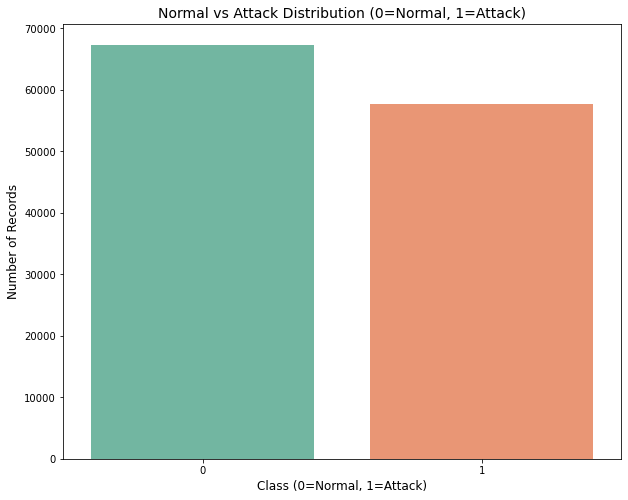

In [16]:
# Create attack_binary column
df_train['attack_binary'] = df_train['outcome'].apply(lambda x: 0 if x == 'normal' else 1)

plt.figure(figsize=(10, 8))
sns.countplot(
    x='attack_binary',
    data=df_train,
    palette="Set2"
)
plt.title("Normal vs Attack Distribution (0=Normal, 1=Attack)", fontsize=14)
plt.xlabel("Class (0=Normal, 1=Attack)", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.show()


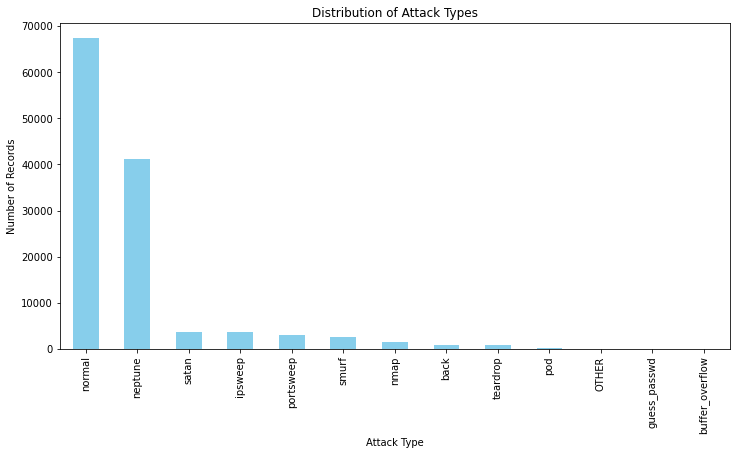

In [17]:
label_count = df_train['outcome'].value_counts()

plt.figure(figsize=(12, 6))
label_count.plot(kind='bar', color='skyblue')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Number of Records')
plt.show()


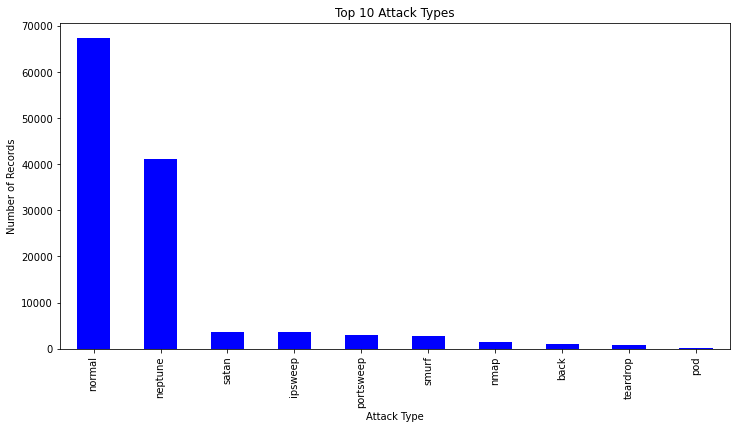

In [18]:
attack_col = 'outcome'
top_attacks = df_train[attack_col].value_counts().head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
top_attacks.plot(kind='bar', color='blue')
plt.title('Top 10 Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Number of Records')
plt.show()


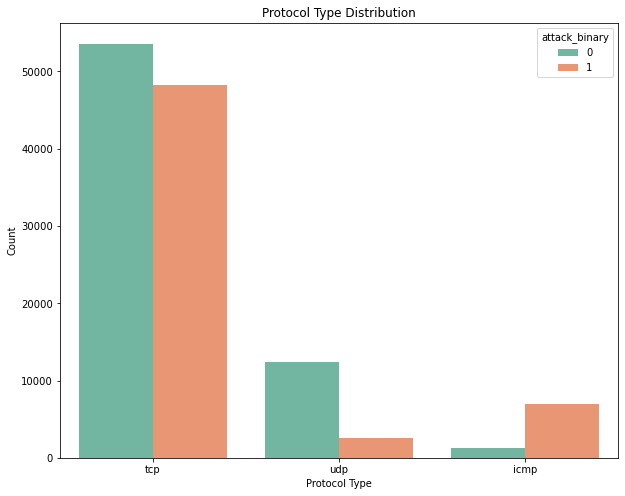

In [19]:
plt.figure(figsize=(10,8))
sns.countplot(x='protocol_type', data=df_train, hue='attack_binary', palette="Set2")
plt.title("Protocol Type Distribution", fontsize=12)
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.show()

In [20]:
#Identify categorical vs. numerical features
categorical_features = df_train.select_dtypes(include=['object']).columns.tolist()
numerical_features = df_train.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)


Categorical Features: ['protocol_type', 'service', 'flag', 'outcome']
Numerical Features: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_binary']


In [21]:
# Create schema mapping table
binary = {"land", "logged_in", "root_shell", "su_attempted", "is_host_login", "is_guest_login"}
drop = {"num_outbound_cmds", "is_host_login", "level"}
special = {"src_bytes": "Log-transform + Normalize", "dst_bytes": "Log-transform + Normalize"}
labels = {"outcome": "Label encode", "category": "Label encode"}

def infer_type(col, s):
    if col in binary:
        return "Binary"
    if s.dtype == "object":
        return "Categorical"
    return "Numerical"

def preprocessing(col, t):
    if col in drop:
        return "Drop"
    if col in special:
        return special[col]
    if col in labels:
        return labels[col]
    if t == "Binary":
        return "Keep as is (0/1)"
    if t == "Categorical":
        return "One-hot encode / Label encode"
    if t == "Numerical":
        return "Already normalized" if "_rate" in col else "Normalize/Standardize"
    return "Check"

schema = [
    {
        "Feature": c,
        "Type": infer_type(c, df_train[c]),
        "Preprocessing": preprocessing(c, infer_type(c, df_train[c])),
        "Semantic": "Label" if c in ["outcome", "category"] else "Feature"
    }
    for c in df_train.columns
]
schema_df = pd.DataFrame(schema)
display(schema_df)


,Feature,Type,Preprocessing,Semantic
0,duration,Numerical,Normalize/Standardize,Feature
1,protocol_type,Categorical,One-hot encode / Label encode,Feature
2,service,Categorical,One-hot encode / Label encode,Feature
3,flag,Categorical,One-hot encode / Label encode,Feature
4,src_bytes,Numerical,Log-transform + Normalize,Feature
5,dst_bytes,Numerical,Log-transform + Normalize,Feature
6,land,Binary,Keep as is (0/1),Feature
7,wrong_fragment,Numerical,Normalize/Standardize,Feature
8,urgent,Numerical,Normalize/Standardize,Feature
9,hot,Numerical,Normalize/Standardize,Feature


In [22]:
#Identify and handle missing values in NSL-KDD dataset
for col in df_train.columns:
    if df_train[col].isnull().sum() > 0:
        if df_train[col].dtype == 'object':
            df_train[col].fillna(df_train[col].mode()[0], inplace=True)
        else:
            df_train[col].fillna(df_train[col].median(), inplace=True)
print("Missing values in df_train handled.")

for col in df_test.columns:
    if df_test[col].isnull().sum() > 0:
        if df_test[col].dtype == 'object':
            df_test[col].fillna(df_test[col].mode()[0], inplace=True)
        else:
            df_test[col].fillna(df_test[col].median(), inplace=True)
print("Missing values in df_test handled.")


Missing values in df_train handled.
Missing values in df_test handled.


In [23]:
# Remove dplicate rows
df_train = df_train.drop_duplicates()
print("Duplicates removed from df_train. Current shape:", df_train.shape)

df_test = df_test.drop_duplicates()
print("Duplicates removed from df_test. Current shape:", df_test.shape)


Duplicates removed from df_train. Current shape: (125081, 43)
Duplicates removed from df_test. Current shape: (18794, 42)


# Binary classification

In [24]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col] = le.transform(df_test[col])

print("df_train shape after Label Encoding:", df_train.shape)
print("df_test shape after Label Encoding:", df_test.shape)
print(df_train[categorical_cols].head())


df_train shape after Label Encoding: (125081, 43)
df_test shape after Label Encoding: (18794, 42)
   protocol_type  service  flag
0              1       20     9
1              2       44     9
2              1       49     5
3              1       24     9
4              1       24     9


In [25]:
# Create binary attack label: 0 = normal, 1 = any attack
df_train['attack_binary'] = df_train['outcome'].apply(lambda x: 0 if x == 'normal' else 1)
df_test['attack_binary'] = df_test['outcome'].apply(lambda x: 0 if x == 'normal' else 1)

X_b_train = df_train.drop(columns=['outcome', 'attack_binary'])
y_b_train = df_train['attack_binary']

X_b_test = df_test.drop(columns=['outcome', 'attack_binary'])
y_b_test = df_test['attack_binary']

print("X_b_train shape:", X_b_train.shape)
print("y_b_train shape:", y_b_train.shape)
print("X_b_test shape:", X_b_test.shape)
print("y_b_test shape:", y_b_test.shape)


X_b_train shape: (125081, 41)
y_b_train shape: (125081,)
X_b_test shape: (18794, 41)
y_b_test shape: (18794,)


# Train-test split

In [26]:
X_b = df_train.drop(columns=['outcome', 'attack_binary'])
y_b = df_train['attack_binary']

X_b_train, X_b_val, y_b_train, y_b_val = train_test_split(
    X_b, y_b, test_size=0.3, random_state=42, stratify=y_b
)

In [27]:
from imblearn.combine import SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_b_train, y_b_train = smote_tomek.fit_resample(X_b_train, y_b_train)


C:\Users\Hp\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


# ML algorithms

1. Supervised Learning

2. Unsupervised Learning

3. Semi-Supervised Learning

4. Reinforcement Learning

5. Ensemble Learning

# Practice with simple examples
## predicting house prices:


In [28]:
# import linear regression 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data = {
    'Size(sqft)': [750, 800, 1200, 1500, 1800, 2000],
    'Bedrooms': [2, 2, 3, 3, 4, 4],
    'Age': [10, 15, 20, 5, 8, 12],
    'Price': [150000, 160000, 200000, 250000, 300000, 320000]
}

df = pd.DataFrame(data)
X = df[['Size(sqft)', 'Bedrooms', 'Age']]
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Predicted Prices:", y_pred)
print("Mean Squared Error:", mse)
new_house = [[1600, 3, 10]] 
predicted_price = model.predict(new_house)
print("Predicted Price for new house:", predicted_price[0])


Predicted Prices: [138809.52380952 140000.        ]
Mean Squared Error: 262613378.684809
Predicted Price for new house: 257142.85714285713


C:\Users\Hp\AppData\Roaming\Python\Python39\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Customer segmentation :

   CustomerID  AnnualIncome(k$)  SpendingScore  Cluster
0           1                15             39        2
1           2                16             81        2
2           3                45              6        0
3           4                55             77        2
4           5                85             40        0
5           6                90             76        1
6           7               120             20        1
7           8               130             94        1


C:\Users\Hp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


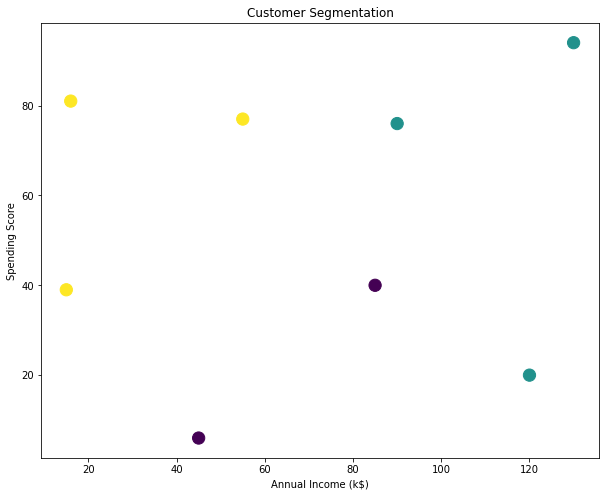

In [29]:
from sklearn.cluster import KMeans
data = {
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8],
    'AnnualIncome(k$)': [15, 16, 45, 55, 85, 90, 120, 130],
    'SpendingScore': [39, 81, 6, 77, 40, 76, 20, 94]
}

df = pd.DataFrame(data)
X = df[['AnnualIncome(k$)', 'SpendingScore']]
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
df['Cluster'] = kmeans.labels_
print(df)
plt.figure(figsize=(10, 8))
plt.scatter(df['AnnualIncome(k$)'], df['SpendingScore'], c=df['Cluster'], cmap='viridis',s=150)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation')
plt.show()

# Logistic regression

In [32]:
df_train['attack_binary'] = df_train['outcome'].apply(lambda x: 0 if x == 'normal' else 1)
df_test['attack_binary'] = df_test['outcome'].apply(lambda x: 0 if x == 'normal' else 1)
X_b_train = df_train.drop(columns=['outcome', 'attack_binary'])
y_b_train = df_train['attack_binary']

X_b_test = df_test.drop(columns=['outcome', 'attack_binary'])
y_b_test = df_test['attack_binary']
X_b_train_split, X_b_val_split, y_b_train_split, y_b_val_split = train_test_split(
    X_b_train, y_b_train, test_size=0.3, random_state=42, stratify=y_b_train
)
scaler = StandardScaler()
X_b_train_scaled = scaler.fit_transform(X_b_train_split)
X_b_val_scaled = scaler.transform(X_b_val_split)
X_b_test_scaled = scaler.transform(X_b_test)

lr = LogisticRegression(max_iter=500, solver="lbfgs")
lr.fit(X_b_train_scaled, y_b_train_split)

y_pred_train = lr.predict(X_b_train_scaled)
print(f"Logistic Regression Training Accuracy: {accuracy_score(y_b_train_split, y_pred_train) * 100:.2f}%")

y_pred_val = lr.predict(X_b_val_scaled)
print(f"Logistic Regression Validation Accuracy: {accuracy_score(y_b_val_split, y_pred_val) * 100:.2f}%")
print(classification_report(y_b_val_split, y_pred_val))

y_pred_test = lr.predict(X_b_test_scaled)
print(f"Logistic Regression Test Accuracy: {accuracy_score(y_b_test, y_pred_test) * 100:.2f}%")
print(classification_report(y_b_test, y_pred_test))

Logistic Regression Training Accuracy: 97.05%
Logistic Regression Validation Accuracy: 96.96%
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     20203
           1       0.97      0.97      0.97     17322

    accuracy                           0.97     37525
   macro avg       0.97      0.97      0.97     37525
weighted avg       0.97      0.97      0.97     37525

Logistic Regression Test Accuracy: 83.77%
              precision    recall  f1-score   support

           0       0.79      0.93      0.86      9711
           1       0.91      0.73      0.81      9083

    accuracy                           0.84     18794
   macro avg       0.85      0.83      0.83     18794
weighted avg       0.85      0.84      0.84     18794



# Decision tree

In [33]:
dt_res = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=None)
dt_res.fit(X_b_train, y_b_train)
y_b_pred_train = dt_res.predict(X_b_train)
print(f"Decision Tree Training Accuracy: {accuracy_score(y_b_train, y_b_pred_train)*100:.2f}%")
y_b_pred_val = dt_res.predict(X_b_val)
print(f"Decision Tree Validation Accuracy: {accuracy_score(y_b_val, y_b_pred_val)*100:.2f}%")
print(classification_report(y_b_val, y_b_pred_val))
y_b_pred_test = dt_res.predict(X_b_test)
print(f"Decision Tree Test Accuracy: {accuracy_score(y_b_test, y_b_pred_test)*100:.2f}%")
print(classification_report(y_b_test, y_b_pred_test))




Decision Tree Training Accuracy: 99.99%
Decision Tree Validation Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20203
           1       1.00      1.00      1.00     17322

    accuracy                           1.00     37525
   macro avg       1.00      1.00      1.00     37525
weighted avg       1.00      1.00      1.00     37525

Decision Tree Test Accuracy: 85.71%
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      9711
           1       0.96      0.73      0.83      9083

    accuracy                           0.86     18794
   macro avg       0.88      0.85      0.85     18794
weighted avg       0.88      0.86      0.85     18794



# Random Forest

In [66]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_b_train, y_b_train)
y_b_pred_train = rf.predict(X_b_train)
print(f"Random Forest Training Accuracy: {accuracy_score(y_b_train, y_b_pred_train)*100:.2f}%")
y_b_pred_val = rf.predict(X_b_val)
print(f"Random Forest Validation Accuracy: {accuracy_score(y_b_val, y_b_pred_val)*100:.2f}%")
print(classification_report(y_b_val, y_b_pred_val))
y_b_pred_test = rf.predict(X_b_test)
print(f"Random Forest Test Accuracy: {accuracy_score(y_b_test, y_b_pred_test)*100:.2f}%")
print(classification_report(y_b_test, y_b_pred_test))


Random Forest Training Accuracy: 99.99%
Random Forest Validation Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20203
           1       1.00      1.00      1.00     17322

    accuracy                           1.00     37525
   macro avg       1.00      1.00      1.00     37525
weighted avg       1.00      1.00      1.00     37525

Random Forest Test Accuracy: 86.59%
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      9711
           1       0.96      0.75      0.84      9083

    accuracy                           0.87     18794
   macro avg       0.88      0.86      0.86     18794
weighted avg       0.88      0.87      0.86     18794



# confusion matrix

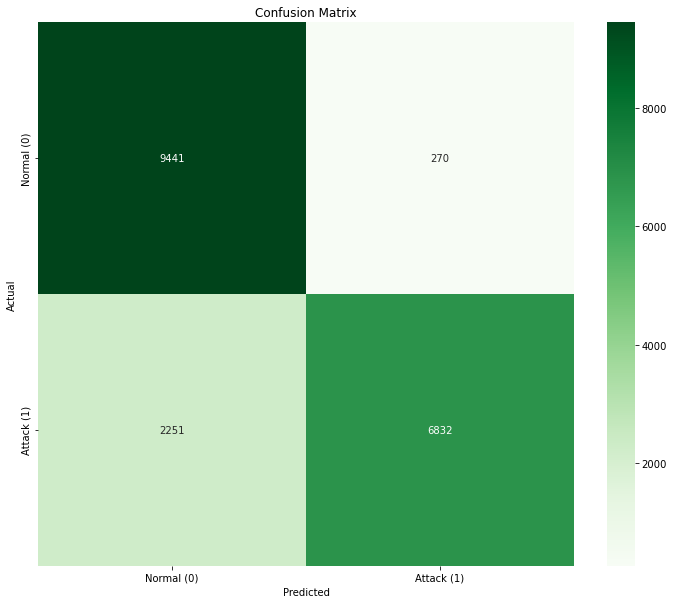

In [38]:
cm_test = confusion_matrix(y_b_test, y_b_pred_test)

plt.figure(figsize=(12,10))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Normal (0)", "Attack (1)"],
            yticklabels=["Normal (0)", "Attack (1)"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# ROC

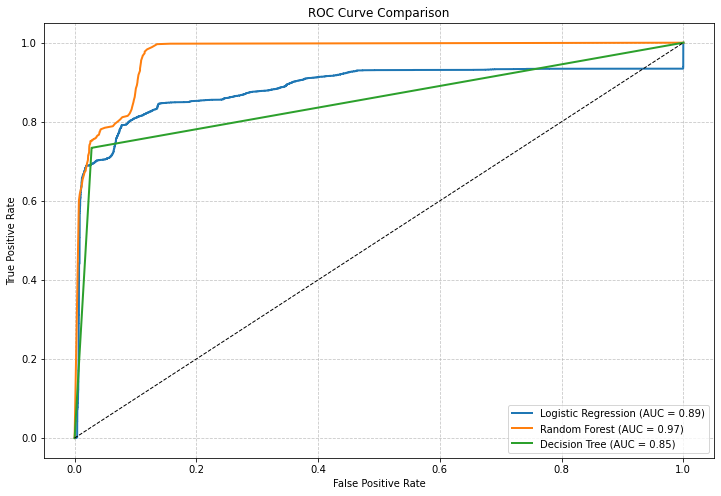

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_prob_lr = lr.predict_proba(X_b_test_scaled)[:, 1]
y_prob_rf = rf.predict_proba(X_b_test)[:, 1]
y_prob_dt = dt_res.predict_proba(X_b_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_b_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_b_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_dt, tpr_dt, _ = roc_curve(y_b_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(12, 8))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})", lw=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})", lw=2)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


# Box plot

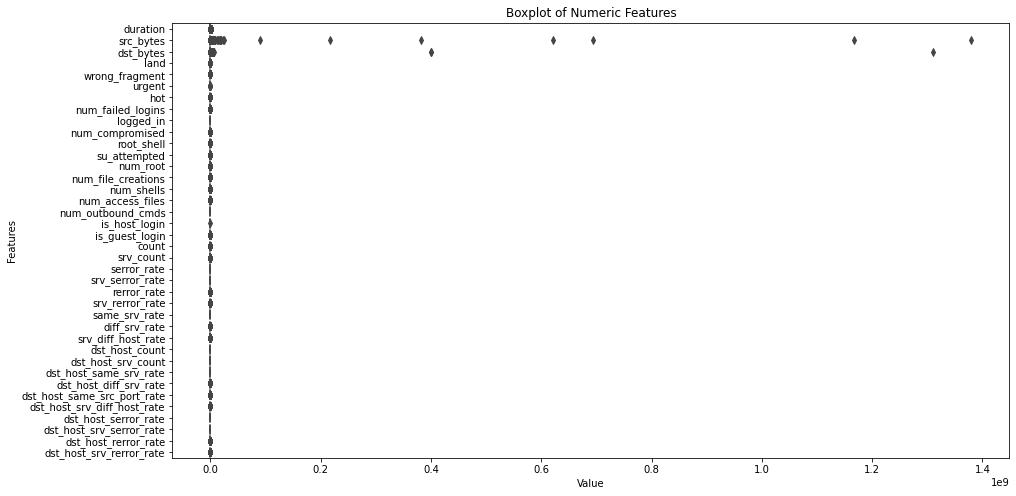

In [40]:
numeric_cols = [
    col for col in df_train.columns 
    if df_train[col].dtype in ['int64', 'float64'] 
    and col not in ['attack_binary']
]

df_melted = df_train[numeric_cols].melt(var_name="Feature", value_name="Value")

plt.figure(figsize=(15, 8))
sns.boxplot(x="Value", y="Feature", data=df_melted, orient="h")
plt.title("Boxplot of Numeric Features")
plt.xlabel("Value")
plt.ylabel("Features")
plt.show()

# Correlation HeatMap


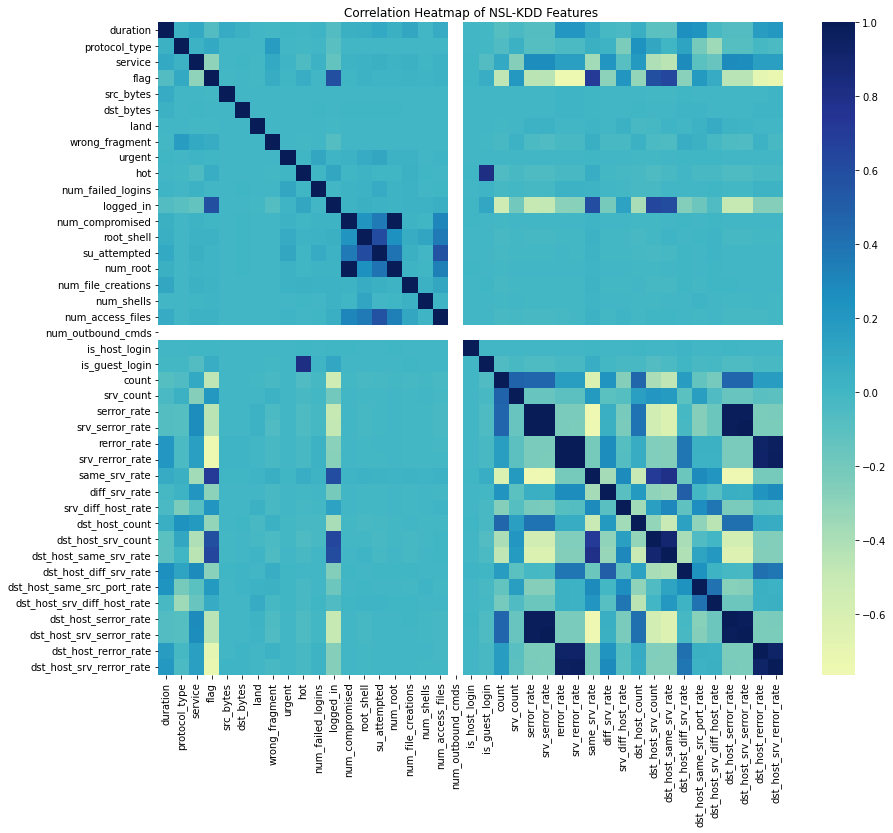

In [41]:
plt.figure(figsize=(14, 12))
corr = pd.DataFrame(X_b_train, columns=X_b.columns).corr()
sns.heatmap(corr, cmap='YlGnBu', center=0, annot=False, fmt=".2f", cbar=True)
plt.title('Correlation Heatmap of NSL-KDD Features')
plt.show()



# Multiclass classification

In [42]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 125081 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125081 non-null  int64  
 1   protocol_type                125081 non-null  int32  
 2   service                      125081 non-null  int32  
 3   flag                         125081 non-null  int32  
 4   src_bytes                    125081 non-null  int64  
 5   dst_bytes                    125081 non-null  int64  
 6   land                         125081 non-null  int64  
 7   wrong_fragment               125081 non-null  int64  
 8   urgent                       125081 non-null  int64  
 9   hot                          125081 non-null  int64  
 10  num_failed_logins            125081 non-null  int64  
 11  logged_in                    125081 non-null  int64  
 12  num_compromised              125081 non-null  int64  
 13 

# # Separate features and target

In [43]:
X = df_train.drop(columns=['outcome','attack_binary'])
y = df_train['outcome']
X_m = df_test.drop(columns=['outcome', 'attack_binary'])
y_m = df_test['outcome']

# Label encode outcome

In [44]:
le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['OTHER' 'back' 'buffer_overflow' 'guess_passwd' 'ipsweep' 'neptune'
 'nmap' 'normal' 'pod' 'portsweep' 'satan' 'smurf' 'teardrop']


In [58]:
le_test = LabelEncoder()
y_m = le_test.fit_transform(y_m) 
print("classes:",le.classes_)


classes: ['OTHER' 'back' 'buffer_overflow' 'guess_passwd' 'ipsweep' 'neptune'
 'nmap' 'normal' 'pod' 'portsweep' 'satan' 'smurf' 'warezmaster']


In [53]:
# Train-Test-Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("External test set shape:", X_m.shape)


Training set shape: (87556, 41)
Validation set shape: (37525, 41)
External test set shape: (18794, 41)


In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_m_scaled = scaler.transform(X_m)
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver='saga', n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
}
results = {
    "Model": [],
    "Train Accuracy": [],
    "Validation Accuracy": [],
    "Test Accuracy": []
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)
    y_test_pred = model.predict(X_m_scaled)
    
    results["Model"].append(name)
    results["Train Accuracy"].append(round(accuracy_score(y_train, y_train_pred)*100, 2))
    results["Validation Accuracy"].append(round(accuracy_score(y_val, y_val_pred)*100, 2))
    results["Test Accuracy"].append(round(accuracy_score(y_m, y_test_pred)*100, 2))
    
    print(f"\n=== {name} ===")
    print("Validation Classification Report:")
    print(classification_report(y_val, y_val_pred))
accuracy_df = pd.DataFrame(results)
accuracy_df = accuracy_df.sort_values(by="Test Accuracy", ascending=False)
print("\n=== Model Accuracy Comparison ===")
print(accuracy_df)

C:\Users\Hp\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== Logistic Regression ===
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.44      0.56        27
           1       0.95      0.60      0.73       287
           2       0.83      0.56      0.67         9
           3       0.89      1.00      0.94        16
           4       0.94      0.94      0.94      1080
           5       1.00      1.00      1.00     12364
           6       0.85      0.81      0.83       448
           7       0.98      0.99      0.98     20203
           8       1.00      0.93      0.97        60
           9       0.98      0.95      0.96       879
          10       0.92      0.88      0.90      1090
          11       0.97      0.98      0.97       794
          12       1.00      1.00      1.00       268

    accuracy                           0.98     37525
   macro avg       0.93      0.85      0.88     37525
weighted avg       0.98      0.98      0.98     37525


=== Decision Tr


=== Multi-Class Validation ===

[1/3] Training Logistic Regression for multi-class...
Logistic Regression Results:
  Training Accuracy: 0.9603 (96.03%)
  Validation Accuracy: 0.9600 (96.00%)
  Training Time: 128.53 seconds
  Overfitting Check: 0.0003

[2/3] Training Decision Tree for multi-class...
Decision Tree Results:
  Training Accuracy: 0.9901 (99.01%)
  Validation Accuracy: 0.9897 (98.97%)
  Training Time: 1.53 seconds
  Overfitting Check: 0.0004

[3/3] Training Random Forest for multi-class...
Random Forest Results:
  Training Accuracy: 0.9298 (92.98%)
  Validation Accuracy: 0.9275 (92.75%)
  Training Time: 2.55 seconds
  Overfitting Check: 0.0023


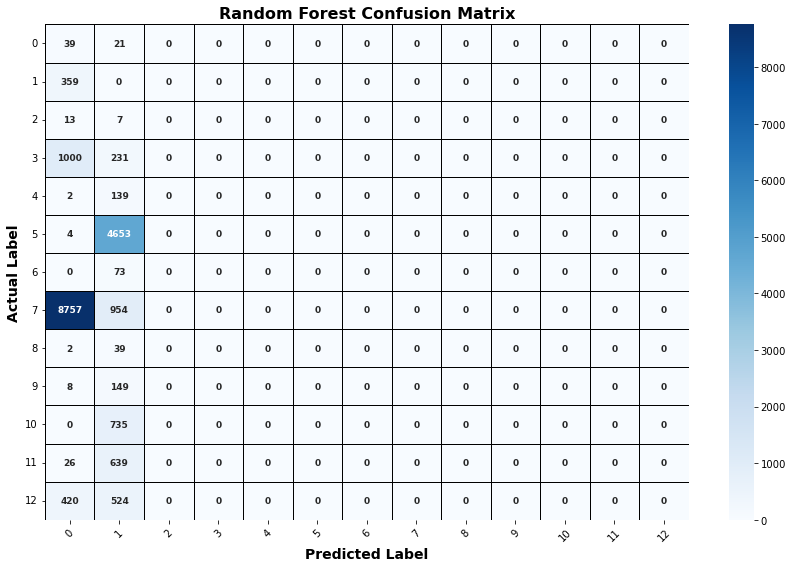

In [69]:
X_m_scaled_df = pd.DataFrame(X_m_scaled, columns=X_train.columns)

y_pred_rf_test = rf.predict(X_m_scaled_df)
cm_rf = confusion_matrix(y_m, y_pred_rf_test)

plt.figure(figsize=(12,8))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=True,
            annot_kws={"size":9, "weight":"bold"}, linewidths=0.5, linecolor="black")
plt.xlabel("Predicted Label", fontsize=14, weight="bold")
plt.ylabel("Actual Label", fontsize=14, weight="bold")
plt.title("Random Forest Confusion Matrix", fontsize=16, weight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Encode all classes together ---
all_classes = np.unique(np.concatenate([y_train, y_val, y_m]))
le = LabelEncoder()
le.fit(all_classes)

y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)
y_m_enc = le.transform(y_m)

# --- Scale features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_m_scaled = scaler.transform(X_m)

# --- Models ---
multi_models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver='saga', n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
}

# --- Train models and get predictions ---
results = {"Model": [], "Train Accuracy": [], "Validation Accuracy": [], "Test Accuracy": []}

for name, model in multi_models.items():
    model.fit(X_train_scaled, y_train_enc)
    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)
    y_test_pred = model.predict(X_m_scaled)
    
    results["Model"].append(name)
    results["Train Accuracy"].append(round(accuracy_score(y_train_enc, y_train_pred)*100, 2))
    results["Validation Accuracy"].append(round(accuracy_score(y_val_enc, y_val_pred)*100, 2))
    results["Test Accuracy"].append(round(accuracy_score(y_m_enc, y_test_pred)*100, 2))

accuracy_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)
print(accuracy_df)

cm_rf = confusion_matrix(y_m_enc, multi_models["Random Forest"].predict(X_m_scaled))
plt.figure(figsize=(12,8))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=True,
            annot_kws={"size":9, "weight":"bold"}, linewidths=0.5, linecolor="black")
plt.xlabel("Predicted Label", fontsize=14, weight="bold")
plt.ylabel("Actual Label", fontsize=14, weight="bold")
plt.title("Random Forest Confusion Matrix", fontsize=16, weight="bold")
plt.xticks(ticks=np.arange(len(le.classes_))+0.5, labels=le.classes_, rotation=45)
plt.yticks(ticks=np.arange(len(le.classes_))+0.5, labels=le.classes_, rotation=0)
plt.tight_layout()
plt.show()

# --- Multi-class ROC curve (micro-average per model) ---
plt.figure(figsize=(10,8))
colors = sns.color_palette("Set2", len(multi_models))

y_m_bin = label_binarize(y_m_enc, classes=range(len(le.classes_)))
n_classes = y_m_bin.shape[1]

for i, (name, model) in enumerate(multi_models.items()):
    y_prob = model.predict_proba(X_m_scaled)
    fpr, tpr, _ = roc_curve(y_m_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=colors[i], label=f'{name} (Micro-avg AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', lw=2, label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (Micro-average)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Training and Testing Evaluation with Accuracy & Classification Report (Multi Class)

In [59]:
# =========================
# MULTI-CLASS CLASSIFICATION - FULL WORKFLOW
# =========================

import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print("=== MULTI-CLASS CLASSIFICATION ===")

# -------------------------
# 1️⃣ Prepare multi-class data
# -------------------------
X_train_multi = X_train      # Already scaled training features
y_train_multi = df_encoded.loc[X_train.index, 'Label']  # Original multi-class labels

X_test_multi = X_test        # Already scaled test features
y_test_multi = df_encoded.loc[X_test.index, 'Label']   # Original multi-class labels

# Print class distributions
print("Multi-class distribution in training set:")
print(y_train_multi.value_counts())
print("\nMulti-class distribution in test set:")
print(y_test_multi.value_counts())

# -------------------------
# 2️⃣ Train-validation split
# -------------------------
X_train_mc, X_val_mc, y_train_mc, y_val_mc = train_test_split(
    X_train_multi, y_train_multi, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_multi
)

print(f"\nTraining shape: {X_train_mc.shape}")
print(f"Validation shape: {X_val_mc.shape}")
print(f"Test shape: {X_test_multi.shape}")

# -------------------------
# 3️⃣ Define models
# -------------------------
multi_models = {
    'Logistic Regression': LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42, multi_class='multinomial'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# -------------------------
# 4️⃣ Evaluation function
# -------------------------
def evaluate_multi_detailed_metrics(models, X_train, y_train, X_test, y_test):
    print("\n=== FINAL TEST EVALUATION ===")
    detailed_results = {}
    
    # Suppress warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        for name, model in models.items():
            print(f"\nEvaluating {name} on test set...")
            
            # Train model
            model.fit(X_train, y_train)
            
            # Test predictions
            y_test_pred = model.predict(X_test)
            
            # Basic accuracy
            test_accuracy = accuracy_score(y_test, y_test_pred)
            
            # Detailed metrics
            precision_macro = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
            recall_macro = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
            f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
            
            precision_weighted = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
            recall_weighted = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
            f1_weighted = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
            
            # Store results
            detailed_results[name] = {
                'accuracy': test_accuracy,
                'precision_macro': precision_macro,
                'recall_macro': recall_macro,
                'f1_macro': f1_macro,
                'precision_weighted': precision_weighted,
                'recall_weighted': recall_weighted,
                'f1_weighted': f1_weighted
            }
            
            # Print classification report
            print(f"{name} Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
            print("Classification Report:")
            print(classification_report(y_test, y_test_pred, digits=2, zero_division=0))
            
            # Optional: print confusion matrix
            cm = confusion_matrix(y_test, y_test_pred)
            print("Confusion Matrix:")
            print(cm)
    
    return detailed_results

# -------------------------
# 5️⃣ Run evaluation on test set
# -------------------------
multi_detailed_results = evaluate_multi_detailed_metrics(
    multi_models, 
    X_train_mc, 
    y_train_mc, 
    X_test_multi, 
    y_test_multi
)

# -------------------------
# 6️⃣ Optional: print summary table
# -------------------------
import pandas as pd
summary_df = pd.DataFrame(multi_detailed_results).T
print("\n=== Summary of Multi-Class Metrics ===")
print(summary_df)


=== MULTI-CLASS CLASSIFICATION ===


NameError: name 'df_encoded' is not defined

# Training vs Testing Accuracy (Percentage)

In [36]:
def evaluate_multi_final_test(models, X_train, y_train, X_test, y_test):
    print("\n=== Multi-Class Final Test Evaluation ===")
    test_results = {}
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        train_accuracy = accuracy_score(y_train, y_train_pred)
        
        y_test_pred = model.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        
        test_results[name] = test_accuracy
        
        print(f"{name} Training Accuracy: {train_accuracy*100:.2f}%")
        print(f"{name} Testing Accuracy: {test_accuracy*100:.2f}%")
        
    return test_results

multi_test_results = evaluate_multi_final_test(
    multi_models, 
    X_train_mc_scaled, y_train_mc, 
    X_test_multi_scaled, y_test_multi
)


=== Multi-Class Final Test Evaluation ===

Evaluating Logistic Regression...
Logistic Regression Training Accuracy: 96.03%
Logistic Regression Testing Accuracy: 69.73%

Evaluating Decision Tree...
Decision Tree Training Accuracy: 99.01%
Decision Tree Testing Accuracy: 69.48%

Evaluating Random Forest...
Random Forest Training Accuracy: 92.98%
Random Forest Testing Accuracy: 71.14%


# Model Accuracy Comparison (Multi-Class Classification)

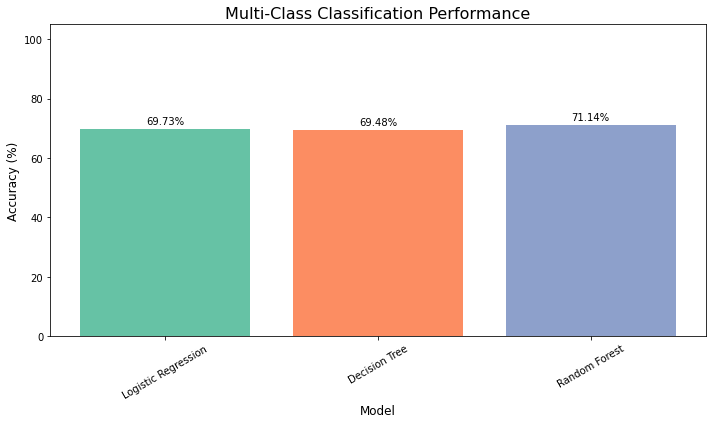


=== Multi-Class Performance Summary ===
Logistic Regression: 69.73%
Decision Tree: 69.48%
Random Forest: 71.14%


In [38]:
multi_results_df = pd.DataFrame([
    {'Model': name, 'Accuracy': acc * 100} 
    for name, acc in multi_test_results.items()
])

plt.figure(figsize=(10, 6))
bars = plt.bar(multi_results_df['Model'], multi_results_df['Accuracy'])

# Apply Set3 colors for multi-class (different from binary)
colors = sns.color_palette("Set2", len(multi_results_df))
for i, bar in enumerate(bars):
    bar.set_facecolor(colors[i])

plt.title('Multi-Class Classification Performance', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 105)
plt.xticks(rotation=30)

# Add accuracy labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print multi-class summary
print("\n=== Multi-Class Performance Summary ===")
for name, acc in multi_test_results.items():
    print(f"{name}: {acc*100:.2f}%")